# 02 — MNIST Handwritten Digit Classifier

MNIST is 70,000 grayscale images of handwritten digits (0–9), each 28×28 pixels. Your job: build a CNN that looks at an image and correctly identifies which digit it is.

This is different from notebook 01 (iris flowers) in two ways:
- The input is an **image**, not a table of numbers
- You'll build a **CNN** (convolutional neural network) instead of a plain feedforward network

It's also different from the ResNet work in notebook 03 — here you build and train the network **from scratch**, so you understand every layer.

By the end you should hit ~99% accuracy on the test set.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Use MPS (Apple GPU) if available, otherwise CPU
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: mps


## Step 1: Load the Data

MNIST is built into torchvision — it downloads automatically on first run (~11MB).

The transform does two things:
- `ToTensor()` — converts the image to a tensor and scales pixel values from [0, 255] to [0.0, 1.0]
- `Normalize((0.1307,), (0.3081,))` — shifts values using MNIST's mean and std, same idea as the ImageNet normalization you saw in notebook 03

Notice there's only **one** mean and std value (not three) — because MNIST is grayscale, so there's only one channel.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

train_dataset = datasets.MNIST(root='/Users/zlee/LocalAi/data/mnist', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='/Users/zlee/LocalAi/data/mnist', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f'Training samples: {len(train_dataset)}')
print(f'Test samples:     {len(test_dataset)}')
print(f'Image shape:      {train_dataset[0][0].shape}')  # [C, H, W]

Training samples: 60000
Test samples:     10000
Image shape:      torch.Size([1, 28, 28])


## Step 2: Visualize Some Samples

Always look at your data before training. You want to sanity-check that it loaded correctly and get a feel for what the model will see.

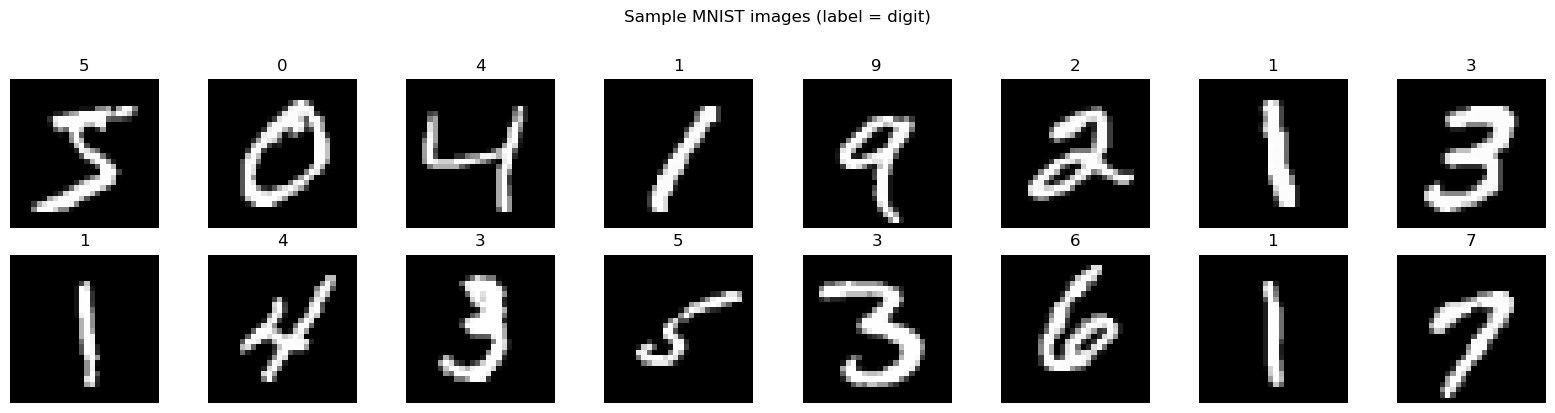

In [4]:
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    ax.imshow(image.squeeze(), cmap='gray')  # squeeze removes the channel dim for display
    ax.set_title(str(label), fontsize=12)
    ax.axis('off')
plt.suptitle('Sample MNIST images (label = digit)', y=1.02)
plt.tight_layout()
plt.show()

## Step 3: Build the CNN

A CNN has two stages:

**Stage 1 — Feature extraction (convolutional layers)**  
These layers scan across the image looking for patterns — edges, curves, loops. Each layer learns to detect more complex features than the last. Think of it as the network learning to ask: "does this patch of pixels look like the top of a 3? The curve of an 8?"

**Stage 2 — Classification (fully connected layers)**  
Once features are extracted, flatten everything into a 1D vector and pass it through regular linear layers — same as the iris network in notebook 01. These layers combine the detected features to make a final decision.

New pieces you haven't seen yet:
- `nn.Conv2d(in, out, kernel_size)` — the convolutional layer. Slides a small filter (e.g. 3×3) across the image and learns what to look for
- `nn.MaxPool2d(2)` — downsamples by taking the max value in each 2×2 block. Shrinks the image while keeping the strongest features
- `nn.ReLU()` — activation function. Sets any negative number to 0. Keeps the network non-linear
- `nn.Dropout(0.25)` — randomly zeroes out 25% of neurons during training. Prevents overfitting
- `nn.Flatten()` — collapses the 2D feature maps into a 1D vector so the linear layers can use them

In [5]:
class MnistCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # Stage 1: Feature extraction
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # 1 input channel (grayscale), 32 filters
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 28x28 → 14x14

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 32 → 64 filters
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 14x14 → 7x7

            # Stage 2: Classification
            nn.Flatten(),                                 # 64 filters × 7×7 = 3136 values
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, 10),                           # 10 output classes (digits 0-9)
        )

    def forward(self, x):
        return self.net(x)

model = MnistCNN().to(device)
print(model)

# Count total trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters: {total_params:,}')

MnistCNN(
  (net): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=3136, out_features=128, bias=True)
    (8): ReLU()
    (9): Dropout(p=0.25, inplace=False)
    (10): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total parameters: 421,642


## Step 4: Train the Model

Same training loop pattern as notebook 01, with one key difference: **we loop over batches** within each epoch (same adaptation you made for CIFAR-10).

MNIST has 60,000 training images. With batch size 64, that's ~937 batches per epoch. Each batch does one forward pass + one backprop + one weight update.

5 epochs is enough to get to ~99% accuracy — the network learns fast on MNIST.

Epoch 1/2  Loss: 0.1565
Epoch 2/2  Loss: 0.0565


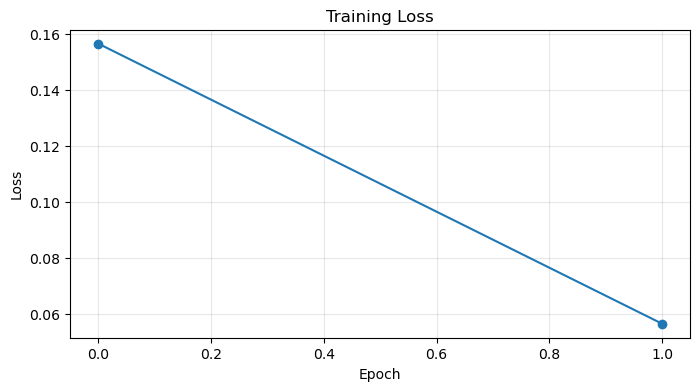

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

n_epochs = 2
train_losses = []

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f'Epoch {epoch+1}/{n_epochs}  Loss: {avg_loss:.4f}')

# Plot the loss curve
plt.figure(figsize=(8, 4))
plt.plot(train_losses, marker='o')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.show()

## Step 5: Evaluate on the Test Set

The test set has 10,000 images the model has never seen. This is the real measure of how well it learned — not the training loss.

Same evaluation pattern as notebook 01: switch to `eval()` mode, disable gradients with `torch.no_grad()`, compare predicted vs actual labels.

In [7]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

print(f'Test Accuracy: {correct/total:.1%}  ({correct}/{total} correct)')

Test Accuracy: 98.8%  (9882/10000 correct)


## Step 6: Look at Predictions

Visualize what the model actually predicted vs the true label. Green = correct, red = wrong.

With ~99% accuracy you'll mostly see green — but the red ones are interesting. They're usually images that are genuinely ambiguous even to humans (a messy 4 that looks like a 9, etc.).

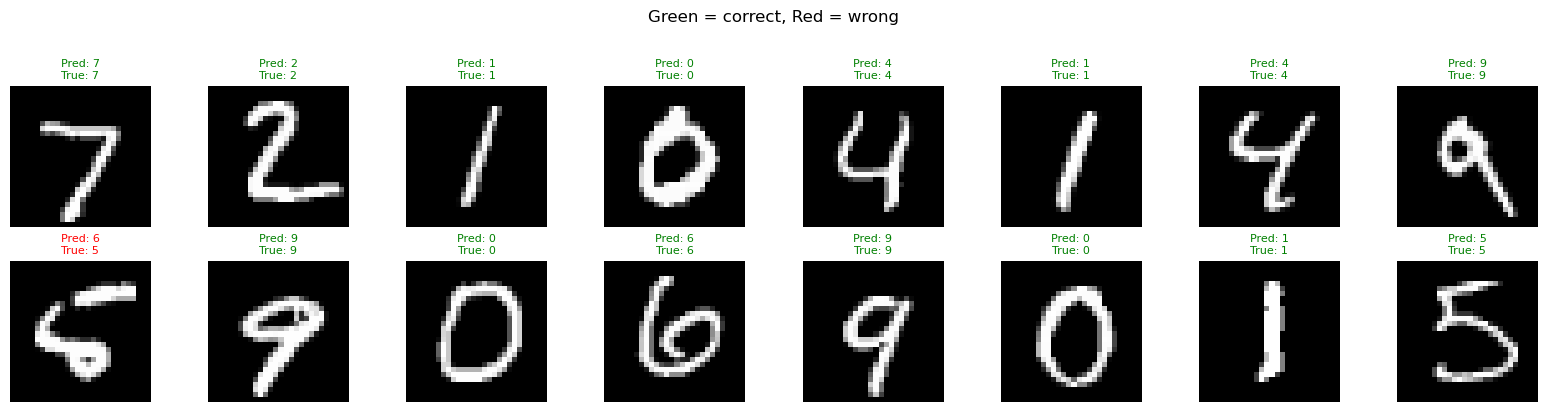

In [8]:
# Grab one batch from the test set
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(
    device)

model.eval()
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].cpu().squeeze(), cmap='gray')
    color = 'green' if predicted[i] == labels[i] else 'red'
    ax.set_title(f'Pred: {predicted[i].item()}\nTrue: {labels[i].item()}', fontsize=8, color=color)
    ax.axis('off')
plt.suptitle('Green = correct, Red = wrong', y=1.02)
plt.tight_layout()
plt.show()

## What You Built

A CNN from scratch that:
- Takes a 28×28 grayscale image
- Extracts features with two convolutional layers
- Classifies into 10 digits with ~99% accuracy

The same fundamental architecture — conv layers for features, linear layers for classification — is what powers much more complex vision models. ResNet (which you used in notebook 03) is just a much deeper version of this same idea.

## Things to Try

1. **Add a third conv layer** — does accuracy improve?
2. **Change the learning rate** — try `lr=0.01` or `lr=0.0001` and watch how the loss curve changes
3. **Increase dropout** to `0.5` — does it help or hurt?
4. **Train for more epochs** — at what point does the loss stop improving?